In [51]:
import logging
import os
import time
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import psutil

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    datefmt="%H:%M:%S",
)

log = logging.getLogger("skyline_insights")

def show_memory(label: str ="") -> None:
    rss_mb = psutil.Process(os.getpid()).memory_info().rss / 1e6
    log.info("Memory in use%s: %.1f MB", f"({label})" if label else "", rss_mb)

def df_size(df: pd.DataFrame, name: str= "df") -> None:
    mb = df.memory_usage(deep=True).sum() / 1e6
    log.info("%s: %s rows x %s cols, %.2f MB in memory", name, f"{len(df):,}", df.shape[1], mb)


sns.set_theme(style="whitegrid")
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

show_memory("notebook start")
log.info("Setup completed")

21:35:48 - INFO - Memory in use(notebook start): 141.5 MB
21:35:48 - INFO - Setup completed


In [ ]:
%time overture = pd.read_csv(DATA_DIR / "overture_nyc_raw.csv")
df_size(overture, "pluto")
show_memory("after PLUTO load")
pluto.head()


19:38:38 - INFO - pluto: 50,000 rows x 10 cols, 9.53 MB in memory
19:38:38 - INFO - Memory in use(after PLUTO load): 134.9 MB


CPU times: total: 172 ms
Wall time: 215 ms


,borough,block,lot,yearbuilt,numfloors,bldgclass,landuse,latitude,longitude,landmark
0,QN,8786,42,1945,2.0,A1,1.0,40.734612,-73.710532,NaN
1,QN,8786,46,1945,1.5,A0,1.0,40.734392,-73.710468,NaN
2,QN,8786,51,1945,1.5,A0,1.0,40.734486,-73.710861,NaN
3,QN,8798,2,1945,1.5,A0,1.0,40.732733,-73.711186,NaN
4,QN,8798,3,1945,1.5,A0,1.0,40.732843,-73.711251,NaN


In [4]:
pluto.describe(include="all")

,borough,block,lot,yearbuilt,numfloors,bldgclass,landuse,latitude,longitude,landmark
count,50000,50000.00000,50000.000000,50000.00000,49715.000000,50000,49909.000000,49933.000000,49933.000000,867
unique,5,NaN,NaN,NaN,NaN,195,NaN,NaN,NaN,3
top,BK,NaN,NaN,NaN,NaN,C0,NaN,NaN,NaN,INDIVIDUAL LANDMARK
freq,23036,NaN,NaN,NaN,NaN,4986,NaN,NaN,NaN,828
mean,NaN,3450.77378,188.275800,1912.53712,3.086264,NaN,2.265363,40.711865,-73.933080,NaN
std,NaN,3375.70549,1004.052834,36.15847,2.226767,NaN,2.026610,0.068473,0.073770,NaN
min,NaN,1.00000,1.000000,1801.00000,0.000000,NaN,1.000000,40.501425,-74.254614,NaN
25%,NaN,1076.00000,18.000000,1890.00000,2.000000,NaN,1.000000,40.668578,-73.978267,NaN
50%,NaN,1931.00000,36.000000,1910.00000,3.000000,NaN,1.000000,40.692906,-73.949913,NaN
75%,NaN,5229.00000,59.000000,1930.00000,3.500000,NaN,2.000000,40.766069,-73.899920,NaN


In [5]:
pluto.dtypes

borough          str
block          int64
lot            int64
yearbuilt      int64
numfloors    float64
bldgclass        str
landuse      float64
latitude     float64
longitude    float64
landmark         str
dtype: object

In [6]:
total_rows = len(pluto)
print(f"Total rows loaded is {total_rows}")

borough_count = pluto["borough"].value_counts()
print(f"\nBoroughs counts {borough_count}")

year_built_min, year_built_max = pluto["yearbuilt"].min(), pluto["yearbuilt"].max()
print(f"\nYearbuilt range is between {year_built_min} - {year_built_max}")

print(f"\n Counts of Nulls:")
null_count = pluto.isna().sum()
print(f"\nMissing rows are: \n{null_count}")

Total rows loaded is 50000

Boroughs counts borough
BK    23036
QN    11181
MN    10817
BX     4082
SI      884
Name: count, dtype: int64

Yearbuilt range is between 1801 - 2025

 Counts of Nulls:

Missing rows are: 
borough          0
block            0
lot              0
yearbuilt        0
numfloors      285
bldgclass        0
landuse         91
latitude        67
longitude       67
landmark     49133
dtype: int64


In [7]:
%time overture = pd.read_csv(DATA_DIR / "overture_nyc_buildings_raw.csv", dtype={"borough_guess":str})
df_size(overture, "overture")
show_memory("after Overture load")
overture.head()

CPU times: total: 5.72 s
Wall time: 7.95 s


19:38:51 - INFO - overture: 1,719,788 rows x 9 cols, 467.38 MB in memory
19:38:51 - INFO - Memory in use(after Overture load): 399.0 MB


,id,height,num_floors,roof_shape,class,subtype,longitude,latitude,borough_guess
0,20798687-6267-4459-8734-d16edf2dec5c,10.6,NaN,NaN,detached,residential,-74.241096,40.498478,SI
1,3739c2b9-a908-4715-958f-b393ad1f10f0,7.7,NaN,NaN,house,residential,-74.254566,40.505180,SI
2,a84ff3f4-8b26-4651-ac6a-4fe0d242743f,NaN,NaN,NaN,greenhouse,agricultural,-74.254611,40.505012,SI
3,4aae9149-6677-4c9a-a95e-4768155d7e41,8.3,NaN,NaN,house,residential,-74.254205,40.505172,SI
4,8de6603c-d98c-4862-8e00-d4ac7b8e746a,2.2,NaN,NaN,garage,residential,-74.254283,40.505045,SI


In [14]:
print(overture.dtypes)

id                   str
height           float64
num_floors       float64
roof_shape           str
class                str
subtype              str
longitude        float64
latitude         float64
borough_guess        str
dtype: object


In [9]:
total_rows = len(overture)
print(f"Total rows loaded is {total_rows}")

borough_guess_count = overture["borough_guess"].value_counts()
print(f"\nBoroughs Guess counts {borough_guess_count}")

print(f"\n Counts of Nulls Overture:")
null_count = overture.isna().sum()
print(f"\nMissing rows are: \n{null_count}")

print(f"\n Counts of Nulls for height:")
null_count = overture["height"].isna().mean()
print(f"\nMissing rows are: \n{null_count *100}")


print(f"\n Counts of Nulls for Num_Floors:")
null_count = overture["num_floors"].isna().mean()
print(f"\nMissing rows are: \n{null_count * 100}")

Total rows loaded is 1719788

Boroughs Guess counts borough_guess
QN    425203
BK    422982
SI    165793
MN    140330
BX    133137
Name: count, dtype: int64

 Counts of Nulls Overture:

Missing rows are: 
id                     0
height            105498
num_floors       1694737
roof_shape       1715151
class            1311092
subtype          1306381
longitude              0
latitude               0
borough_guess     432343
dtype: int64

 Counts of Nulls for height:

Missing rows are: 
6.134360746789721

 Counts of Nulls for Num_Floors:

Missing rows are: 
98.54336697313855


In [ ]:
# Data Quality Audit - Pluto
total_rows_pluto = len(pluto)

unchecked_cols = ["numfloors", "landuse", "latitude", "longitude"]

for col in unchecked_cols:
    n_null = pluto[col].isna().sum()
    null_pct = round((n_null / total_rows) * 100, 2)
    print(f"{col:12s}: {n_null:5,} nulls {null_pct}% of rows")

print(f"\n {'landmark':12s}: {pluto['landmark'].notna().sum():5,} landmark designated ({pluto['landmark'].notna().sum()/ total_rows:5.1%}) of rows")

zero_floors = len(pluto[pluto["numfloors"] == 0])
print(f"\nBuildings with zero floors: {zero_floors}")

numfloors   :   285 nulls 0.57% of rows
landuse     :    91 nulls 0.18% of rows
latitude    :    67 nulls 0.13% of rows
longitude   :    67 nulls 0.13% of rows

 landmark    :   867 landmark designated ( 1.7%) of rows

Buildings with zero floors: 2


In [31]:
# Data Quality Audit - Pluto
total_rows_overture = len(overture)

unchecked_cols = ["height", "num_floors", "class", "subtype", "borough_guess"]

for col in unchecked_cols:
    n_null = overture[col].isna().sum()
    null_pct = round((n_null / total_rows_overture) * 100, 2)
    print(f"{col:12s}: {n_null:5,} nulls {null_pct}% of rows")

zero_floors = len(overture[overture["num_floors"] == 0])
print(f"\nBuildings with zero floors: {zero_floors}")


lower_height = overture[overture["height"] < 1.0]
top_height =  overture[overture["height"] >  200.0]   # Possible buildings (similar to PLUTO)

print(f" Height < 1.0m : {len(lower_height)} rows, ({len(lower_height)/total_rows_overture:.3%})")
print(f" Height > 200.0m : {len(top_height)} rows, ({len(top_height)/total_rows_overture:.3%})")


# Which classes of buildings are skyscrapers(buidlings with the top height)
print(f"\nKinds of the tallest building in overture data")
print(overture.nlargest(5,"height")[["height", "class", "subtype", "borough_guess"]])

height      : 105,498 nulls 6.13% of rows
num_floors  : 1,694,737 nulls 98.54% of rows
class       : 1,311,092 nulls 76.24% of rows
subtype     : 1,306,381 nulls 75.96% of rows
borough_guess: 432,343 nulls 25.14% of rows

Buildings with zero floors: 0
 Height < 1.0m : 3438 rows, (0.200%)
 Height > 200.0m : 83 rows, (0.005%)

Kinds of the tallest building in overture data
         height        class      subtype borough_guess
1019369   472.0   apartments  residential            MN
933392    443.2       office   commercial            MN
1019278   435.4   apartments  residential            MN
1018844   426.0  residential  residential            MN
1018316   423.0          NaN          NaN            MN


In [36]:
FLOOR_HEIGHT_M = 3.5

overture["estimated_floors"] = overture["height"] / FLOOR_HEIGHT_M
print(overture[["height", "estimated_floors"]].describe())

tallest = overture.nlargest(1, "height").iloc[0]
print(f"\n")
print(f"tallest building in overture is: {tallest['height']:.1f}m, {tallest['height']/FLOOR_HEIGHT_M:.0f} floors")

             height  estimated_floors
count  1.614290e+06      1.614290e+06
mean   7.424618e+00      2.121319e+00
std    5.660045e+00      1.617156e+00
min    1.027749e-03      2.936426e-04
25%    4.635131e+00      1.324323e+00
50%    6.966281e+00      1.990366e+00
75%    8.800000e+00      2.514286e+00
max    4.720000e+02      1.348571e+02


tallest building in overture is: 472.0m, 135 floors


In [49]:
# Aggregation

BOROUGH_NAMES = {
    "MN": "Manhattan",
    "BK": "Brooklyn",
    "QN": "Queens",
    "BX": "Bronx",
    "SI": "Staten Island"
}

def aggregate_to_brough(
        df: pd.DataFrame,
        source_name: str,
        floors_col: str,
        borough_col: str,
        year_col: str | None = None
):
    agg_spec={
        "n_buildings": (borough_col, "size"),
        "avg_floors":  (floors_col, "mean"),
        "median_floors": (floors_col, "median")
    }

    if year_col is not None:
        agg_spec["avg_year_built"] = (year_col, "mean")

    agg = (
        df.groupby(borough_col)
        .agg(**agg_spec)
        .reset_index()
        .rename(columns={borough_col: "borough_code"})
    )

    agg["borough_name"] = agg["borough_code"].map(BOROUGH_NAMES)
    agg["source"] = source_name
    agg["avg_floors"] = agg["avg_floors"].round(2)

    if year_col is not None:
            agg["avg_year_built"] = agg["avg_year_built"].round(1)

    cols = ["borough_code", "borough_name", "n_buildings", "avg_floors", "median_floors"]
    if year_col is not None:
                cols.append("avg_year_built")
    cols.append("source")
    return agg[cols].sort_values("n_buildings", ascending=False).reset_index(drop=True)


In [46]:
pluto_borough_agg = aggregate_to_brough(pluto, source_name="PLUTO", floors_col="numfloors", borough_col="borough", year_col="yearbuilt")

pluto_borough_agg

,borough_code,borough_name,n_buildings,avg_floors,median_floors,avg_year_built,source
0,BK,Brooklyn,23036,2.78,3.0,1906.1,PLUTO
1,QN,Queens,11181,2.18,2.0,1937.9,PLUTO
2,MN,Manhattan,10817,4.94,4.0,1889.0,PLUTO
3,BX,Bronx,4082,2.62,2.0,1935.1,PLUTO
4,SI,Staten Island,884,2.10,2.0,1944.1,PLUTO


In [50]:
overture_borough_agg = aggregate_to_brough(overture, source_name="OVERTURE", floors_col="estimated_floors", borough_col="borough_guess")

overture_borough_agg

,borough_code,borough_name,n_buildings,avg_floors,median_floors,source
0,QN,Queens,425203,1.83,1.885714,OVERTURE
1,BK,Brooklyn,422982,2.32,2.314286,OVERTURE
2,SI,Staten Island,165793,2.04,2.142857,OVERTURE
3,MN,Manhattan,140330,3.82,2.828571,OVERTURE
4,BX,Bronx,133137,2.26,2.228571,OVERTURE


21:58:52 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
21:58:52 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


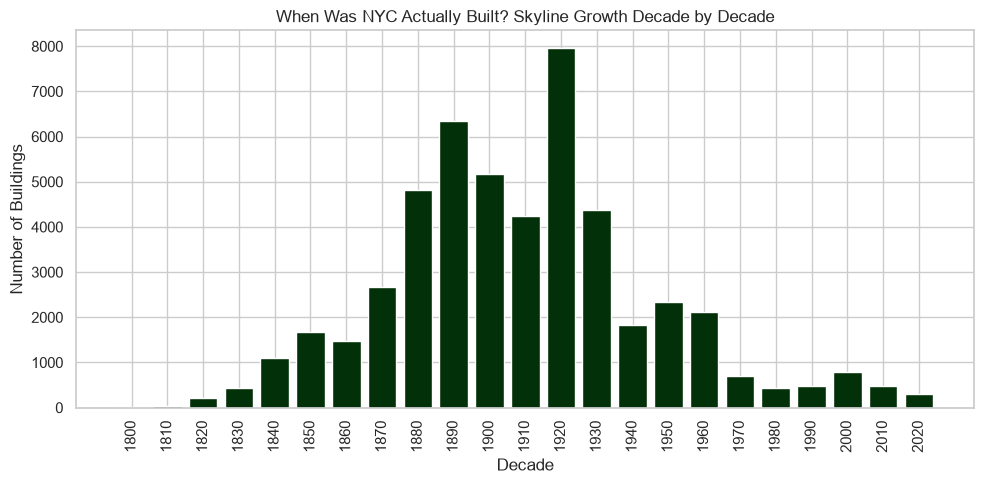

In [57]:
fig, ax = plt.subplots(figsize=(10,5))
decade = (pluto["yearbuilt"] // 10 * 10).astype(int)
decade_counts = decade.value_counts().sort_index()
ax.bar(decade_counts.index.astype(str), decade_counts.values, width=0.8, color="#023109")
ax.set_title("When Was NYC Actually Built? Skyline Growth Decade by Decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Number of Buildings")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()


In [58]:
pluto_decades = pluto.copy()
pluto_decades["decade"] = (pluto["yearbuilt"] // 10 * 10).astype(int)
pluto_decades["borough_name"] = pluto_decades["borough"].map(BOROUGH_NAMES)

skyline_by_decade = (
    pluto_decades.groupby(["decade", "borough_name"])["numfloors"]
    .mean()
    .reset_index()
)

skyline_by_decade

,decade,borough_name,numfloors
0,1800,Manhattan,3.734375
1,1810,Bronx,1.500000
2,1810,Brooklyn,3.000000
3,1810,Manhattan,3.513889
4,1820,Brooklyn,3.109375
...,...,...,...
99,2020,Bronx,6.720000
100,2020,Brooklyn,5.460145
101,2020,Manhattan,12.150000
102,2020,Queens,4.516949


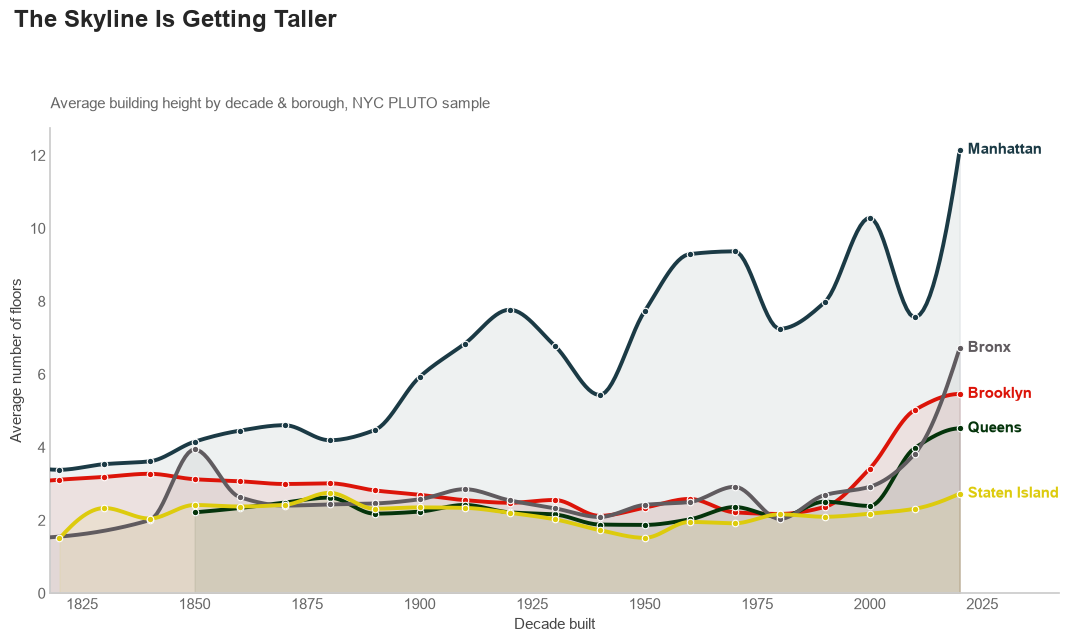

In [60]:
BOROUGH_COLORS = {
    "Manhattan": "#1B3A45",
    "Brooklyn": "#DC1409",
    "Queens": "#04340B",
    "Bronx": "#605B5F",
    "Staten Island": "#DDCB0D"
}

from scipy.interpolate import PchipInterpolator

fig, ax = plt.subplots(figsize=(11,6.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for borough, color in BOROUGH_COLORS.items():
    series = skyline_by_decade[skyline_by_decade["borough_name"] == borough].sort_values("decade")
    x,y = series["decade"].to_numpy(dtype=float), series["numfloors"].to_numpy(dtype=float)

    x_smooth = np.linspace(x.min(), x.max(), 300)
    y_smooth = PchipInterpolator(x, y)(x_smooth)

    ax.plot(x_smooth, y_smooth, color=color, linewidth=2.8, solid_capstyle="round", zorder=3)
    ax.fill_between(x_smooth, y_smooth, 0, color=color, alpha=0.07, zorder=1)
    ax.scatter(x, y, color=color, s=22, zorder=4, edgecolor="white", linewidth=0.8)

    ax.annotate(f"  {borough}", xy=(x[-1], y[-1]), color=color,
                fontsize=10.5, fontweight="bold", va="center", ha="left")

fig.suptitle("The Skyline Is Getting Taller", fontsize=17, fontweight="bold", x=0.02, y=0.985, ha="left")
ax.set_title("Average building height by decade & borough, NYC PLUTO sample",
             fontsize=10.5, color="#666666", loc="left", pad=14)
ax.set_xlabel("Decade built", fontsize=10.5, color="#444444")
ax.set_ylabel("Average number of floors", fontsize=10.5, color="#444444")
ax.set_xlim(x.min() - 2, x.max() + 22)
ax.set_ylim(0, None)
ax.grid(False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#CCCCCC")
ax.tick_params(colors="#666666", length=0)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(OUTPUT_DIR / "chart_04_skyline_growth_headline.png", dpi=150, facecolor="white")
plt.show()

In [62]:
comparison = pluto_borough_agg.merge(
    overture_borough_agg, on="borough_name", suffixes=("_pluto", "_overture")
)
comparison["building_count_ratio"] = (comparison["n_buildings_overture"] / comparison["n_buildings_pluto"]).round(1)
comparison = comparison[[
    "borough_name",
    "n_buildings_pluto", "n_buildings_overture", "building_count_ratio",
    "avg_floors_pluto", "avg_floors_overture",
]].sort_values("avg_floors_pluto", ascending=False).reset_index(drop=True)
comparison

,borough_name,n_buildings_pluto,n_buildings_overture,building_count_ratio,avg_floors_pluto,avg_floors_overture
0,Manhattan,10817,140330,13.0,4.94,3.82
1,Brooklyn,23036,422982,18.4,2.78,2.32
2,Bronx,4082,133137,32.6,2.62,2.26
3,Queens,11181,425203,38.0,2.18,1.83
4,Staten Island,884,165793,187.5,2.10,2.04


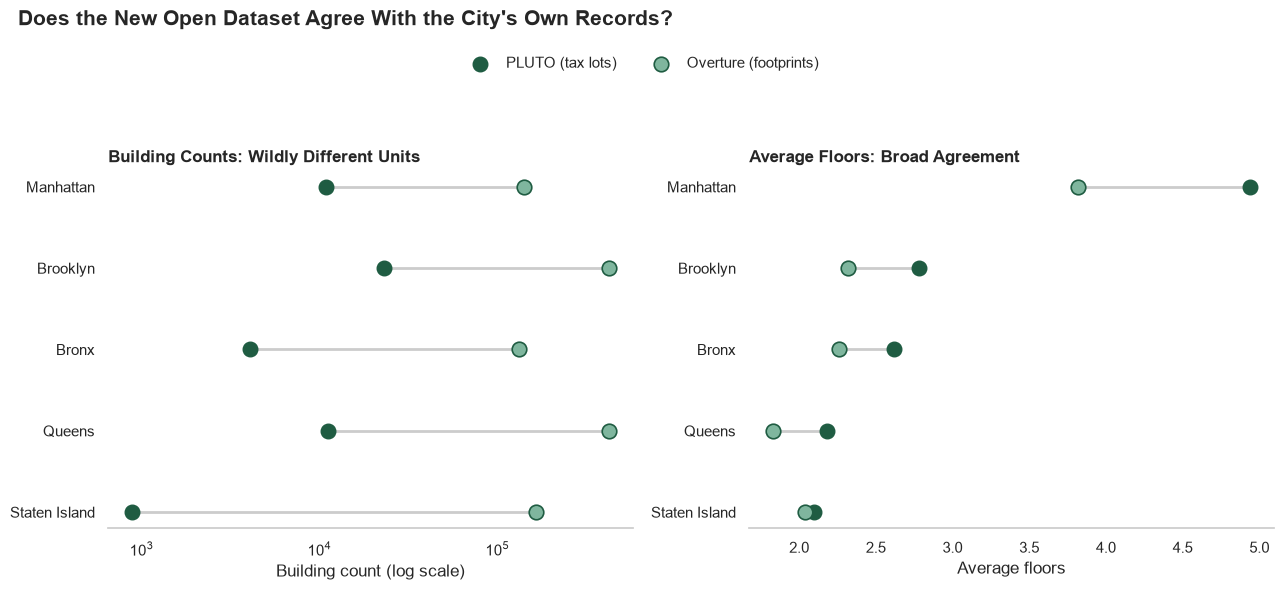

In [64]:
GREEN_PRIMARY = "#1F5C42"
GREEN_SECONDARY = "#7FB69E"
order = comparison.sort_values("avg_floors_pluto", ascending=False)["borough_name"].tolist()
y = np.arange(len(order))[::-1]
c = comparison.set_index("borough_name").loc[order]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.6))
fig.patch.set_facecolor("white")

for yi, borough in zip(y, order):
    row = c.loc[borough]
    ax1.plot([row["n_buildings_pluto"], row["n_buildings_overture"]], [yi, yi],
              color="#CCCCCC", linewidth=2, zorder=1)
ax1.scatter(c["n_buildings_pluto"], y, s=110, color=GREEN_PRIMARY, zorder=3, label="PLUTO (tax lots)")
ax1.scatter(c["n_buildings_overture"], y, s=110, color=GREEN_SECONDARY, zorder=3,
            edgecolor=GREEN_PRIMARY, linewidth=1.2, label="Overture (footprints)")
ax1.set_xscale("log")
ax1.set_yticks(y)
ax1.set_yticklabels(order)
ax1.set_xlabel("Building count (log scale)")
ax1.set_title("Building Counts: Wildly Different Units", fontsize=12.5, fontweight="bold", loc="left")
ax1.grid(False)
for spine in ["top", "right", "left"]:
    ax1.spines[spine].set_visible(False)
ax1.tick_params(left=False)

for yi, borough in zip(y, order):
    row = c.loc[borough]
    ax2.plot([row["avg_floors_pluto"], row["avg_floors_overture"]], [yi, yi],
              color="#CCCCCC", linewidth=2, zorder=1)
ax2.scatter(c["avg_floors_pluto"], y, s=110, color=GREEN_PRIMARY, zorder=3, label="PLUTO")
ax2.scatter(c["avg_floors_overture"], y, s=110, color=GREEN_SECONDARY, zorder=3,
            edgecolor=GREEN_PRIMARY, linewidth=1.2, label="Overture (est.)")
ax2.set_yticks(y)
ax2.set_yticklabels(order)
ax2.set_xlabel("Average floors")
ax2.set_title("Average Floors: Broad Agreement", fontsize=12.5, fontweight="bold", loc="left")
ax2.grid(False)
for spine in ["top", "right", "left"]:
    ax2.spines[spine].set_visible(False)
ax2.tick_params(left=False)


handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.99),
           ncol=2, frameon=False, fontsize=10.5)

fig.suptitle("Does the New Open Dataset Agree With the City's Own Records?",
             fontsize=15, fontweight="bold", x=0.02, y=1.05, ha="left")
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(OUTPUT_DIR / "chart_00_trust_check_comparison.png", dpi=150, facecolor="white", bbox_inches="tight")
plt.show()

*Discussion:*

- two panels, two different verdicts, and that contrast *is* the finding.

- This is a **dumbbell chart**; each borough gets one horizontal line with two dots on it, one
per source: chosen deliberately over grouped vertical bars because it puts borough names on
the y-axis (no rotated, crowded x-axis labels to fight with) and makes the *gap itself* the
visual focus, which is exactly what this chart needs to communicate. 

- On the left, the log
x-axis is doing real work: without it, PLUTO's dots would sit invisibly close to zero next to
Overture's; with it, you can still see the gap between the two dots *widen* as boroughs get
less dense, exactly the "different counting units" story from the table above.

- On the right,
a plain linear x-axis is used on purpose - here the two sources' dots sit close together in
every borough, and that visual closeness is the honest, positive half of the trust verdict.

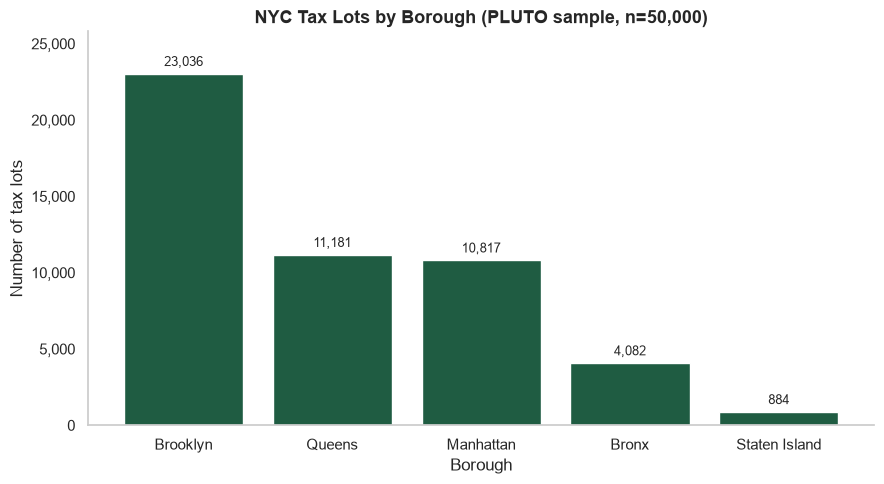

In [65]:
fig, ax = plt.subplots(figsize=(9, 5))
order = pluto_borough_agg.sort_values("n_buildings", ascending=False)
bars = ax.bar(order["borough_name"], order["n_buildings"], color=GREEN_PRIMARY)
ax.set_title("NYC Tax Lots by Borough (PLUTO sample, n=50,000)", fontsize=13, fontweight="bold")
ax.set_xlabel("Borough")
ax.set_ylabel("Number of tax lots")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(bars, order["n_buildings"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 500, f"{val:,}", ha="center", fontsize=9)
ax.set_ylim(0, order["n_buildings"].max() * 1.12)  # headroom so the top label never clips
ax.grid(False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart_01_lots_by_borough.png", dpi=150)
plt.show()

*Discussion*

- "Brooklyn alone accounts for nearly half this sample's tax lots which is more than Queens and Manhattan combined. That's the kind of
one-sentence, mid-scroll-stopping line the editor asked for, and it's true: Brooklyn's 23,036
lots dwarf Staten Island's 884 by a factor of roughly 26 to 1. This chart answers pure *scale*,
not *shape*; it doesn't yet tell us which borough is flat versus vertical, unlike what we did in class

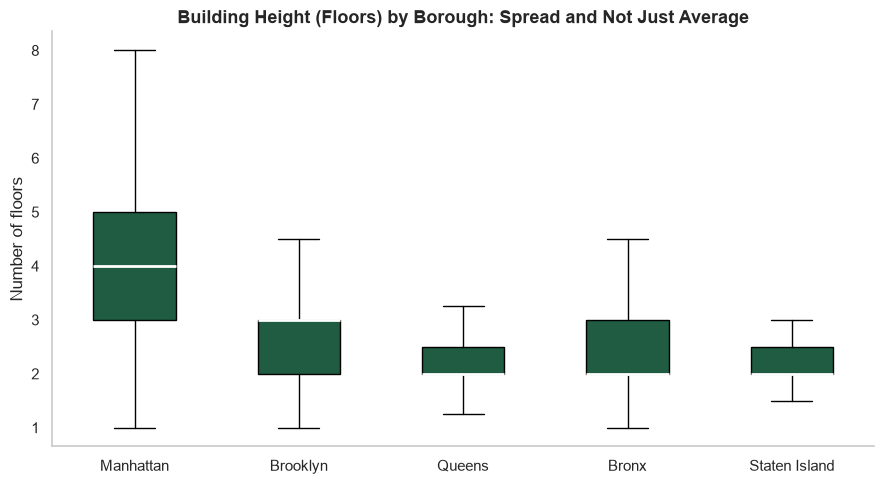

In [67]:
fig, ax = plt.subplots(figsize=(9, 5))
box_data = [pluto.loc[pluto["borough"] == b, "numfloors"].dropna() for b in BOROUGH_NAMES]
bp = ax.boxplot(box_data, tick_labels=list(BOROUGH_NAMES.values()), patch_artist=True, showfliers=False)
for patch in bp["boxes"]:
    patch.set_facecolor(GREEN_PRIMARY)
    patch.set_alpha(1.0)
for median in bp["medians"]:
    median.set_color("white")
    median.set_linewidth(2)
ax.set_title("Building Height (Floors) by Borough: Spread and Not Just Average", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of floors")
ax.grid(False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart_03_floors_boxplot.png", dpi=150)
plt.show()

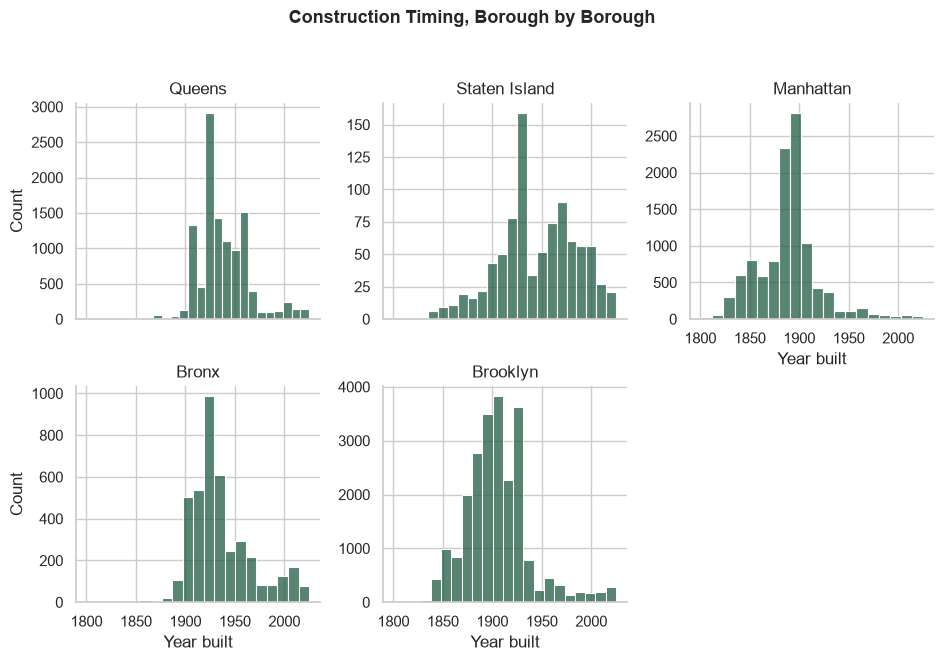

In [68]:
g = sns.FacetGrid(pluto_decades, col="borough_name", col_wrap=3, height=3.2, sharey=False)
g.map(sns.histplot, "yearbuilt", bins=20, color=GREEN_PRIMARY)
g.set_titles("{col_name}")
g.set_axis_labels("Year built", "Count")
g.figure.suptitle("Construction Timing, Borough by Borough", y=1.03, fontsize=13, fontweight="bold")
plt.tight_layout()
g.savefig(OUTPUT_DIR / "chart_05_facet_yearbuilt_by_borough.png", dpi=150)
plt.show()

Tips:

- faceting turns "one crowded chart with five overlapping colors" into
"five small, individually readable charts" 
- useful whenever comparing distributions (not just
single numbers) across a category.
- Look for boroughs whose bars cluster tightly in one era
versus boroughs with a long, spread-out building history. that's a second, independent way of
seeing the same "how did each borough actually grow" story the headline chart above told
with averages.